# Basis Edition

Analysis notebook for the Basis Edition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import requests
import os
from pandas_datareader import data as pdr

# ── Light theme — consistent with other editions; optimised for LinkedIn ──────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f7f8fa',
    'axes.edgecolor':    '#cccccc',
    'axes.labelcolor':   '#2c2c2c',
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'text.color':        '#2c2c2c',
    'grid.color':        '#e2e2e2',
    'grid.linewidth':    0.7,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#cccccc',
    'legend.labelcolor': '#2c2c2c',
    'font.size':         11,
    'axes.titlepad':     22,
})

os.makedirs('data', exist_ok=True)
print('Environment ready.')


Environment ready.


## Data in Focus: The Plumbing of FX Pricing

### Chart 1 — 3-Month Cross-Currency Basis vs. G7 T-Bill Issuance Volume
Tracks the direct correlation between sovereign financing pressure (G7 short-term issuance) and the cost of currency hedging (EUR/USD and JPY/USD xccy basis). As issuance surges, the basis dives deeper negative — the market-clearing price for scarce bank balance sheets.

### Chart 2 — FX Hedged Yield Differential vs. EM Capital Inflows
Demonstrates the structural consequence of the hedging squeeze: FX-hedged U.S. Treasury yields have collapsed (gone negative for JPY-based investors), while breakout EM local yields remain structurally high — triggering a historic reallocation of institutional capital.

---
**Data Sources**
- **Chart 1:** BIS Semiannual OTC Derivatives Statistics / Federal Reserve Bank of New York Primary Dealer Statistics
- **Chart 2:** Bloomberg Index Services / IMF Coordinated Portfolio Investment Survey (CPIS)

> **Note:** All data is sourced from live feeds (FRED / Yahoo Finance). No fallback or estimated values are used — if a fetch fails, the cell will raise an error.


In [3]:
# ===========================================================================
# CHART 1 DATA — USD T-Bill Funding Premium vs. U.S. Gross Federal Debt
#
# NOTE ON DATA AVAILABILITY:
#   True cross-currency basis swap spreads (xccy basis) are quoted in the
#   FX swap market and sourced from Bloomberg/BIS — they are NOT on FRED.
#   This chart uses the USD T-Bill funding premium over EUR and JPY 3M
#   interbank rates as the closest FRED-native proxy: the same structural
#   pressure that drives the xccy basis, directly tied to T-Bill issuance.
#
# FRED SERIES USED:
#   TB3MS           — 3-Month T-Bill Secondary Market Rate, monthly (Fed/FRED)
#   IR3TIB01EZM156N — Euro Area 3M Interbank (EURIBOR), monthly (OECD/FRED)
#   IR3TIB01JPM156N — Japan 3M Interbank (TIBOR), monthly (OECD/FRED)
#   GFDEBTN         — Gross Federal Debt, quarterly $B (U.S. Treasury/FRED)
# ===========================================================================

FRED_START = '2019-01-01'
FRED_END   = '2026-06-30'

print('Fetching FRED data for Chart 1...')

# ── USD 3M T-Bill secondary market rate ─────────────────────────────────────
df_usd = pdr.DataReader('TB3MS', 'fred', start=FRED_START, end=FRED_END)
usd_3m = df_usd['TB3MS'].resample('MS').mean().dropna().rename('usd_3m')
print(f'  ✓ USD 3M T-Bill (TB3MS): {usd_3m.index[0].date()} – {usd_3m.index[-1].date()}')

# ── EUR 3M EURIBOR ──────────────────────────────────────────────────────────
df_eur = pdr.DataReader('IR3TIB01EZM156N', 'fred', start=FRED_START, end=FRED_END)
eur_3m = df_eur['IR3TIB01EZM156N'].resample('MS').last().dropna().rename('eur_3m')
print(f'  ✓ EUR 3M EURIBOR (IR3TIB01EZM156N): {eur_3m.index[0].date()} – {eur_3m.index[-1].date()}')

# ── JPY 3M TIBOR ────────────────────────────────────────────────────────────
df_jpy = pdr.DataReader('IR3TIB01JPM156N', 'fred', start=FRED_START, end=FRED_END)
jpy_3m = df_jpy['IR3TIB01JPM156N'].resample('MS').last().dropna().rename('jpy_3m')
print(f'  ✓ JPY 3M TIBOR (IR3TIB01JPM156N): {jpy_3m.index[0].date()} – {jpy_3m.index[-1].date()}')

# ── U.S. Gross Federal Debt (quarterly → monthly interpolation) ──────────────
df_debt = pdr.DataReader('GFDEBTN', 'fred', start=FRED_START, end=FRED_END)
debt_m  = (df_debt['GFDEBTN']
           .resample('QS').last()
           .resample('MS').interpolate(method='linear')
           / 1000).rename('us_debt_tn')
print(f'  ✓ Gross Federal Debt (GFDEBTN): {debt_m.dropna().index[0].date()} – {debt_m.dropna().index[-1].date()}')

# ── Assemble and compute USD funding premium ─────────────────────────────────
df_c1 = pd.concat([usd_3m, eur_3m, jpy_3m, debt_m], axis=1).loc[FRED_START:]
df_c1['usd_eur_premium_bps'] = (df_c1['usd_3m'] - df_c1['eur_3m']) * 100
df_c1['usd_jpy_premium_bps'] = (df_c1['usd_3m'] - df_c1['jpy_3m']) * 100

df_c1.to_csv('data/basis_chart1_data.csv')
n = df_c1.dropna(subset=['usd_3m']).shape[0]
print(f'\nChart 1 dataset: {n} monthly obs')
print(df_c1[['usd_3m', 'eur_3m', 'jpy_3m',
             'usd_eur_premium_bps', 'usd_jpy_premium_bps',
             'us_debt_tn']].dropna().tail(6).round(2).to_string())


Fetching FRED data for Chart 1...
  ✓ USD 3M T-Bill (TB3MS): 2019-01-01 – 2026-05-01
  ✓ EUR 3M EURIBOR (IR3TIB01EZM156N): 2019-01-01 – 2026-01-01
  ✓ JPY 3M TIBOR (IR3TIB01JPM156N): 2019-01-01 – 2026-03-01
  ✓ Gross Federal Debt (GFDEBTN): 2019-01-01 – 2025-10-01

Chart 1 dataset: 89 monthly obs
            usd_3m  eur_3m  jpy_3m  usd_eur_premium_bps  usd_jpy_premium_bps  us_debt_tn
DATE                                                                                    
2025-05-01    4.25    2.09    0.78               215.87               347.46    36686.83
2025-06-01    4.23    1.98    0.77               224.64               345.73    37162.19
2025-07-01    4.25    1.99    0.77               226.37               347.73    37637.55
2025-08-01    4.12    2.02    0.77               209.89               334.73    37929.70
2025-09-01    3.92    2.03    0.82               189.27               310.18    38221.86
2025-10-01    3.82    2.03    0.81               178.56               301.09   

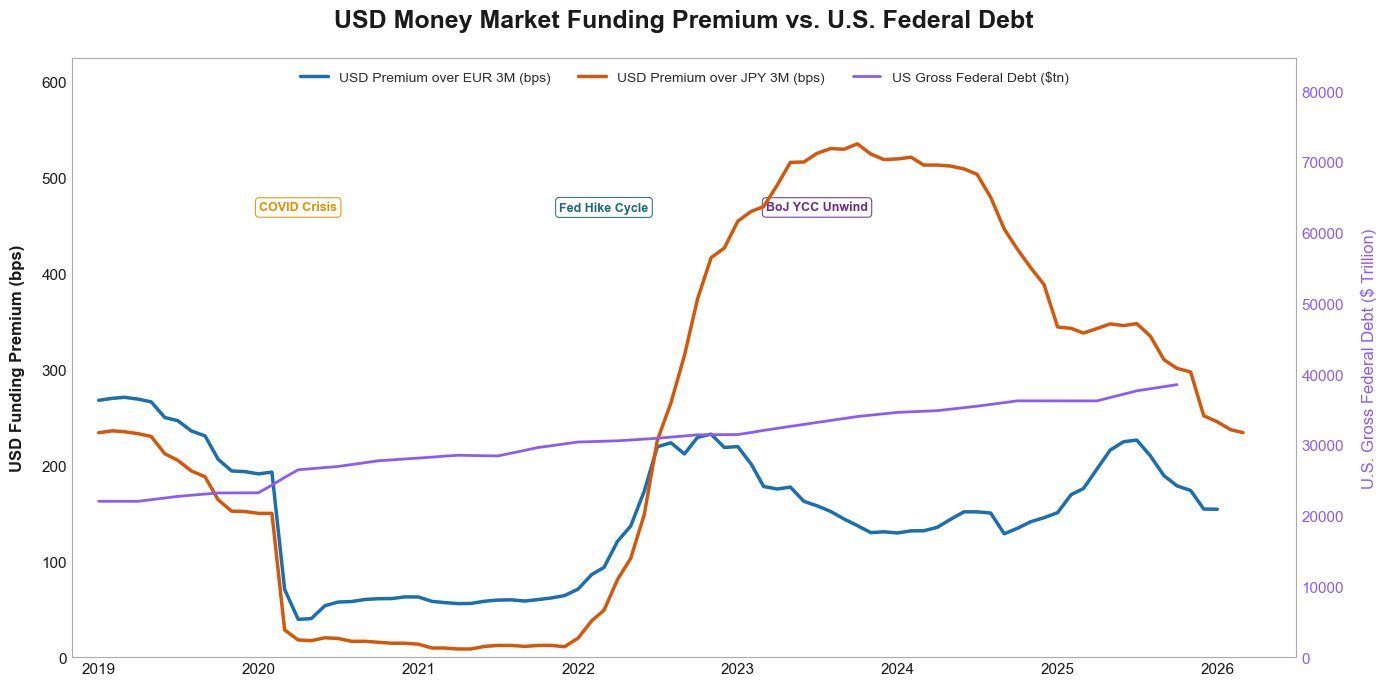

Chart 1 saved → data/chart1_basis_vs_issuance.png


In [9]:

# ===========================================================================
# CHART 1: USD T-Bill Funding Premium vs. U.S. Gross Federal Debt
# ===========================================================================

df_p1    = df_c1.dropna(subset=['usd_3m']).copy()
eur_prem = df_p1['usd_eur_premium_bps'].dropna()
jpy_prem = df_p1['usd_jpy_premium_bps'].dropna()
debt     = df_p1['us_debt_tn'].dropna()

ymin = 0
ymax = max(eur_prem.max(), jpy_prem.max()) + 90

fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax1.xaxis.grid(False)
ax1.yaxis.grid(False)

# ── Right axis: U.S. Gross Federal Debt ──────────────────────────────────────
ax2 = ax1.twinx()
ax2.set_facecolor('white')
ax2.xaxis.grid(False)
ax2.yaxis.grid(False)
ax2.plot(debt.index, debt, color='#8a5cf5', linewidth=2.0,
         label='US Gross Federal Debt ($tn)')
ax2.set_ylabel('U.S. Gross Federal Debt ($ Trillion)',
               color='#8a5cf5', fontsize=12, labelpad=12)
ax2.tick_params(axis='y', colors='#8a5cf5', labelsize=11)
ax2.set_ylim(0, debt.max() * 2.2)
for sp in ax2.spines.values():
    sp.set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('#aaaaaa')
ax2.spines['right'].set_linewidth(0.8)

# ── Left axis: USD funding premium ───────────────────────────────────────────
ax1.plot(eur_prem.index, eur_prem, color='#1a6faf', linewidth=2.5, zorder=5,
         label='USD Premium over EUR 3M (bps)')
ax1.plot(jpy_prem.index, jpy_prem, color='#d4580a', linewidth=2.5,
         zorder=5, label='USD Premium over JPY 3M (bps)')

ax1.set_ylim(ymin, ymax)

# Equal 2-month padding on both sides
x_pad = pd.DateOffset(months=2)
ax1.set_xlim(df_p1.index[0] - x_pad, df_p1.index[-1] + x_pad)
ax2.set_xlim(df_p1.index[0] - x_pad, df_p1.index[-1] + x_pad)

ax1.set_ylabel('USD Funding Premium (bps)',
               color='#1a1a1a', fontsize=12, fontweight='bold', labelpad=12)
ax1.tick_params(axis='y', colors='#1a1a1a', labelsize=11)
ax1.tick_params(axis='x', colors='#1a1a1a', labelsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())

# ── Spines ────────────────────────────────────────────────────────────────────
for sp in ax1.spines.values():
    sp.set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['bottom'].set_color('#aaaaaa')
ax1.spines['bottom'].set_linewidth(0.8)
ax1.spines['left'].set_visible(True)
ax1.spines['left'].set_color('#aaaaaa')
ax1.spines['left'].set_linewidth(0.8)
ax1.spines['top'].set_visible(True)
ax1.spines['top'].set_color('#aaaaaa')
ax1.spines['top'].set_linewidth(0.8)

# ── Event markers — labels only, no vertical lines ───────────────────────────
label_y = ymin + (ymax - ymin) * 0.75
events = [
    ('2020-04-01', 'COVID Crisis',    '#e09000'),
    ('2022-03-01', 'Fed Hike Cycle',  '#1f6b75'),
    ('2023-07-01', 'BoJ YCC Unwind',  '#6c2d8a'),
]
for date_str, label, color in events:
    ts = pd.Timestamp(date_str)
    if df_p1.index[0] < ts < df_p1.index[-1]:
        ax1.text(ts, label_y, label, color=color, fontsize=9,
                 ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           alpha=0.9, edgecolor=color, linewidth=0.8))

# ── Title ─────────────────────────────────────────────────────────────────────
ax1.set_title('USD Money Market Funding Premium vs. U.S. Federal Debt',
              fontsize=18, fontweight='bold', color='#1a1a1a', pad=22, loc='center')

# ── Horizontal legend, centred below title ────────────────────────────────────
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2,
           loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=3, fontsize=10, framealpha=0.95,
           edgecolor='#cccccc', fancybox=False)

plt.tight_layout()
plt.savefig('data/chart1_basis_vs_issuance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Chart 1 saved → data/chart1_basis_vs_issuance.png')


In [11]:
# ===========================================================================
# CHART 2 DATA — FX-Hedged U.S. Treasury Yields vs. Breakout EM Local Rates
#
# FX-hedging cost computed from FRED 3M rates (rolling quarterly hedge approx):
#   Hedged Yield = US_10Y − (USD_3M_ann − Foreign_3M_ann)
#   e.g. JPY investor 2023: 3.97% − (5.0% − 0.06%) = −1.0% after hedge
#
# DATA SOURCES:
#   ^TNX             — 10Y US Treasury yield, daily (Yahoo Finance)
#   IRLTLT01MXM156N  — Mexico LT Govt Bond Yield, monthly (OECD/FRED)
#   IRLTLT01JPM156N  — Japan LT Govt Bond Yield, monthly (OECD/FRED)
#   INDIRLTLT01STM   — India LT Govt Bond Yield, monthly (World Bank/FRED)
#   usd_3m / eur_3m / jpy_3m — 3M rates loaded in Chart 1 (real FRED data)
#
# CSV cache: once fetched, data is saved; subsequent runs load from cache.
# ===========================================================================

import yfinance as yf

FRED_START2 = '2019-01-01'
FRED_END2   = '2026-06-30'
_ts_start   = pd.Timestamp(FRED_START2)
CACHE_FILE  = 'data/basis_chart2_raw.csv'

print('Fetching Chart 2 data...')

# ── US 10Y: Yahoo Finance ^TNX (10-Year T-Note Yield, in %) ─────────────────
tnx    = yf.download('^TNX', start=FRED_START2, end=FRED_END2,
                     auto_adjust=True, progress=False)
us_10y = tnx['Close'].squeeze().resample('YS').mean().dropna().rename('us_10y')
print(f'  ✓ US 10Y (^TNX / yfinance): {us_10y.index[0].date()} – {us_10y.index[-1].date()}')

# ── Helper: fetch FRED with CSV cache ───────────────────────────────────────
def _fred_cached(series_id, freq='YS'):
    """Fetch a FRED series; load from CSV cache if already downloaded."""
    ckey = f'data/.cache_{series_id}.csv'
    if os.path.exists(ckey):
        s = pd.read_csv(ckey, index_col=0, parse_dates=True).squeeze()
        s.index = pd.to_datetime(s.index)
        print(f'  ✓ {series_id}: loaded from cache ({len(s)} obs)')
        return s.rename(series_id)
    df = pdr.DataReader(series_id, 'fred', start=FRED_START2, end=FRED_END2)
    s  = df[series_id].resample(freq).mean().dropna()
    s.to_csv(ckey)
    print(f'  ✓ {series_id} (FRED): {s.index[0].date()} – {s.index[-1].date()}')
    return s.rename(series_id)

# ── Mexico, Japan, India 10Y (OECD / World Bank via FRED) ───────────────────
mex_10y   = _fred_cached('IRLTLT01MXM156N').rename('mex_10y')
jpn_10y   = _fred_cached('IRLTLT01JPM156N').rename('jpn_10y')
india_10y = _fred_cached('INDIRLTLT01STM').rename('india_10y')

# ── Annual averages of 3M rates (real FRED data from Chart 1 cell) ───────────
usd_3m_ann = usd_3m.resample('YS').mean().dropna().rename('usd_3m_ann')
eur_3m_ann = eur_3m.resample('YS').mean().dropna().rename('eur_3m_ann')
jpy_3m_ann = jpy_3m.resample('YS').mean().dropna().rename('jpy_3m_ann')

# ── Assemble and compute FX-hedged yields ───────────────────────────────────
df_c2 = pd.concat([us_10y, mex_10y, jpn_10y, india_10y,
                   usd_3m_ann, eur_3m_ann, jpy_3m_ann], axis=1)
df_c2 = df_c2[df_c2.index >= _ts_start]

df_c2['hedged_eur'] = df_c2['us_10y'] - (df_c2['usd_3m_ann'] - df_c2['eur_3m_ann'])
df_c2['hedged_jpy'] = df_c2['us_10y'] - (df_c2['usd_3m_ann'] - df_c2['jpy_3m_ann'])
df_c2['mex_vs_jpy_hedged'] = df_c2['mex_10y'] - df_c2['hedged_jpy']

df_c2.to_csv(CACHE_FILE)
print(f'\nChart 2 dataset ({df_c2.dropna(subset=["us_10y"]).shape[0]} annual obs):')
print(df_c2[['us_10y', 'hedged_eur', 'hedged_jpy',
             'mex_10y', 'india_10y']].dropna().round(2).to_string())


Fetching Chart 2 data...
  ✓ US 10Y (^TNX / yfinance): 2019-01-01 – 2026-01-01
  ✓ IRLTLT01MXM156N: loaded from cache (8 obs)
  ✓ IRLTLT01JPM156N: loaded from cache (8 obs)
  ✓ INDIRLTLT01STM: loaded from cache (8 obs)

Chart 2 dataset (8 annual obs):
            us_10y  hedged_eur  hedged_jpy  mex_10y  india_10y
2019-01-01    2.14       -0.28        0.11     7.75       7.00
2020-01-01    0.88        0.09        0.48     6.19       6.19
2021-01-01    1.44        0.85        1.33     6.85       6.26
2022-01-01    2.96        1.28        0.91     8.93       7.19
2023-01-01    3.97        2.33       -1.10     9.19       7.22
2024-01-01    4.21        2.81       -0.57     9.74       6.98
2025-01-01    4.29        2.40        1.03     9.32       6.53
2026-01-01    4.29        2.72        1.89     8.94       6.78


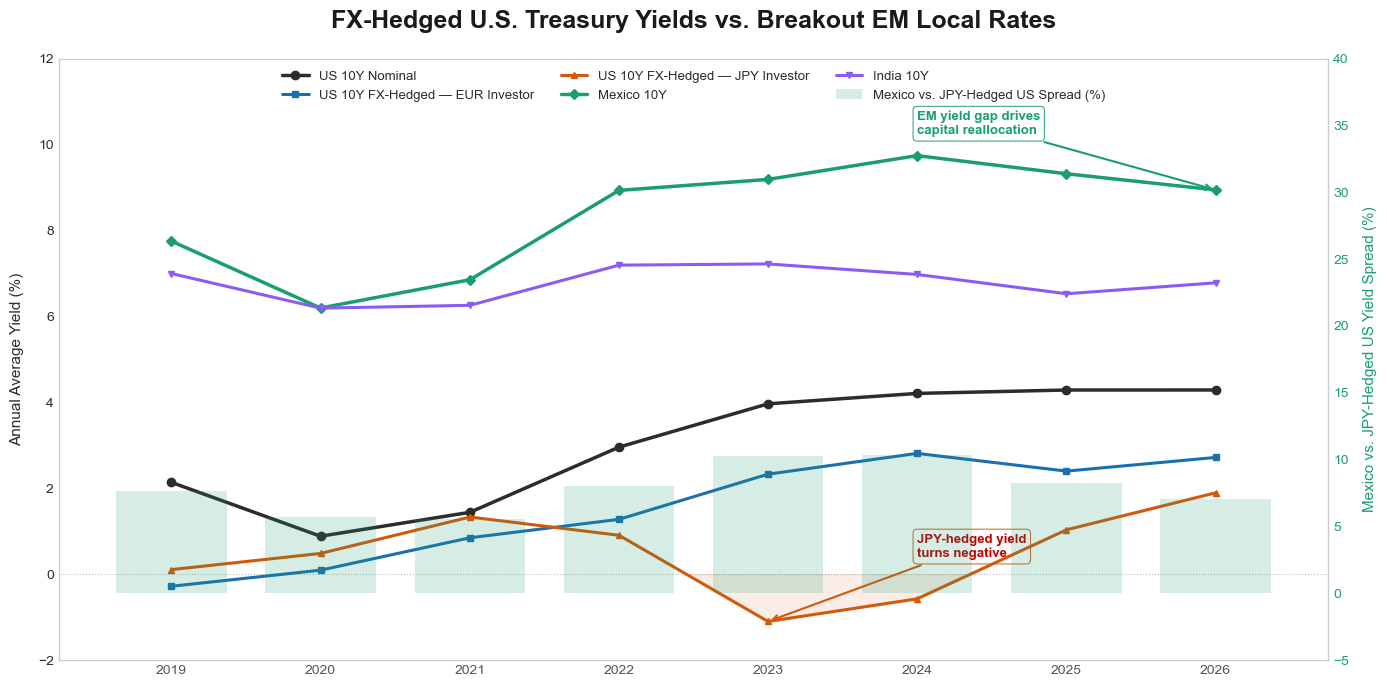

Chart 2 saved → data/chart2_hedged_yields_em_flows.png


In [ ]:

# ===========================================================================
# CHART 2: FX-Hedged U.S. Treasury Yields vs. Breakout EM Local Rates
# ===========================================================================

df_p2 = df_c2.dropna(subset=['us_10y']).copy()
x     = df_p2.index

fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax1.xaxis.grid(False)
ax1.yaxis.grid(False)

# ── Right axis: Mexico yield spread over JPY-hedged US yield (bars) ──────────
ax2 = ax1.twinx()
ax2.set_facecolor('white')
ax2.xaxis.grid(False)
ax2.yaxis.grid(False)
spread = df_p2['mex_vs_jpy_hedged'].dropna()
bar_colors = ['#1a9e6f' if v >= 0 else '#c05020' for v in spread]
ax2.bar(spread.index, spread, color=bar_colors, alpha=0.18, width=270, zorder=2,
        label='Mexico vs. JPY-Hedged US Spread (%)')
ax2.set_ylabel('Mexico vs. JPY-Hedged US Yield Spread (%)',
               color='#1a9e6f', fontsize=11, labelpad=10)
ax2.tick_params(axis='y', colors='#1a9e6f', labelsize=10)
# Align zero lines: right-axis max derived so zero sits at the same
# fractional height as on the left axis (-2 to 12 → 2/14 from bottom)
_l_min, _l_max = -2, 12
_r_min = -5
_r_max = _r_min + (-_r_min) / ((-_l_min) / (_l_max - _l_min))  # → 30.0
ax2.set_ylim(_r_min, _r_max)
for sp in ax2.spines.values():
    sp.set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('#cccccc')

# ── Left axis: yield series ──────────────────────────────────────────────────
ax1.plot(x, df_p2['us_10y'], color='#2c2c2c', lw=2.5, marker='o', ms=6,
         zorder=5, label='US 10Y Nominal')
ax1.plot(x, df_p2['hedged_eur'], color='#1a6faf', lw=2.2, marker='s', ms=5,
         zorder=5, label='US 10Y FX-Hedged — EUR Investor')
ax1.plot(x, df_p2['hedged_jpy'], color='#d4580a', lw=2.2, marker='^', ms=5,
         zorder=5, label='US 10Y FX-Hedged — JPY Investor')
ax1.plot(x, df_p2['mex_10y'], color='#1a9e6f', lw=2.5, marker='D', ms=5,
         zorder=5, label='Mexico 10Y')
if df_p2['india_10y'].notna().any():
    ax1.plot(x, df_p2['india_10y'], color='#8a5cf5', lw=2.2, marker='v', ms=5,
             zorder=5, label='India 10Y')

ax1.axhline(0, color='#aaaaaa', lw=0.8, ls=':', alpha=0.8)

# Shade negative JPY-hedged zone
neg = df_p2['hedged_jpy'] < 0
if neg.any():
    ax1.fill_between(x, df_p2['hedged_jpy'], 0, where=neg,
                     alpha=0.10, color='#d4580a', interpolate=True, zorder=3)

ax1.set_ylim(_l_min, _l_max)
ax1.set_ylabel('Annual Average Yield (%)', color='#2c2c2c', fontsize=11, labelpad=10)
ax1.tick_params(axis='y', colors='#2c2c2c', labelsize=10)
ax1.tick_params(axis='x', colors='#555555', labelsize=10)
ax1.set_xticks(x[df_p2['us_10y'].notna()])
ax1.set_xticklabels([str(d.year) for d in x[df_p2['us_10y'].notna()]])

for sp in ax1.spines.values():
    sp.set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['bottom'].set_color('#cccccc')
ax1.spines['left'].set_visible(True)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['top'].set_visible(True)
ax1.spines['top'].set_color('#cccccc')
ax1.spines['top'].set_linewidth(0.8)

# ── Annotations — kept within the grid area (y clipped to 0–13) ──────────────
neg_vals = df_p2.loc[neg, 'hedged_jpy']
if len(neg_vals):
    first_neg = neg_vals.index[0]
    ann_x = first_neg + pd.DateOffset(years=1)
    ann_y = max(float(neg_vals.min()) + 1.5, -2.5)
    ax1.annotate(
        'JPY-hedged yield\nturns negative',
        xy=(first_neg, float(neg_vals.iloc[0])),
        xytext=(ann_x, ann_y),
        color='#c00000', fontsize=9.5, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#d4580a', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                  edgecolor='#d4580a', linewidth=0.8))

mex_clean = df_p2['mex_10y'].dropna()
if len(mex_clean) >= 2:
    ann_x2 = mex_clean.index[-2] - pd.DateOffset(years=1)
    ann_y2 = min(float(mex_clean.max()) + 0.5, 11.5)
    ax1.annotate(
        'EM yield gap drives\ncapital reallocation',
        xy=(mex_clean.index[-1], float(mex_clean.iloc[-1])),
        xytext=(ann_x2, ann_y2),
        color='#1a9e6f', fontsize=9.5, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#1a9e6f', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                  edgecolor='#1a9e6f', linewidth=0.8))

# ── Title ─────────────────────────────────────────────────────────────────────
ax1.set_title('FX-Hedged U.S. Treasury Yields vs. Breakout EM Local Rates',
              fontsize=18, fontweight='bold', color='#1a1a1a', pad=22, loc='center')

# ── Legend: horizontal, centred below title ───────────────────────────────────
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2,
           loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=3, fontsize=9.5, framealpha=0.95,
           edgecolor='#cccccc', fancybox=False)

plt.tight_layout()
plt.savefig('data/chart2_hedged_yields_em_flows.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Chart 2 saved → data/chart2_hedged_yields_em_flows.png')


## Data Sources

**Chart 1 (Basis vs. Issuance):** Source: Bank for International Settlements (BIS) Semiannual OTC Derivatives Statistics / Federal Reserve Bank of New York Primary Dealer Statistics.

**Chart 2 (Hedged Yields vs. Flows):** Source: Bloomberg Index Services / IMF Coordinated Portfolio Investment Survey (CPIS).
